In [1]:
!pip install -q kagglehub
import json
import os
import random
from pathlib import Path
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)
print(
    "GPU available:",
    bool(tf.config.list_physical_devices("GPU"))
)

TensorFlow version: 2.20.0
GPU available: True


In [3]:
dataset_path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

data_path = Path(dataset_path)

metadata_matches = list(
    data_path.rglob("HAM10000_metadata.csv")
)

if not metadata_matches:
    raise FileNotFoundError(
        "HAM10000_metadata.csv was not found."
    )

metadata_file = metadata_matches[0]

df = pd.read_csv(metadata_file)

print("Dataset downloaded to:", data_path)
print("Metadata file:", metadata_file)

print("\nFirst five rows:")
print(df.head())

print("\nDataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nClass counts:")
print(df["dx"].value_counts())

image_files = list(
    data_path.rglob("*.jpg")
)

if not image_files:
    raise FileNotFoundError(
        "No JPG images were found."
    )

print("\nNumber of images found:", len(image_files))
print("First image path:", image_files[0])

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000
Metadata file: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv

First five rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Dataset shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Number of images found: 20030
First image path: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images

In [4]:
lesion_names = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions",
}
unknown_codes = (
    set(df["dx"].unique())
    - set(lesion_names)
)
if unknown_codes:
    raise ValueError(
        f"Unknown lesion codes found: {unknown_codes}"
    )

In [5]:
image_path_dictionary = {
    image_path.stem: str(image_path)
    for image_path in image_files
}
print("Image paths stored:",
len(image_path_dictionary))

Image paths stored: 10015


In [6]:
df["image_path"] = df["image_id"].map(
    image_path_dictionary
)

missing_paths = df["image_path"].isna().sum()
print(
    "Missing image paths:",
    missing_paths
)

if missing_paths > 0:
    missing_ids = df.loc[
        df["image_path"].isna(),
        "image_id"
    ].head(10)

    raise ValueError(
        "Some metadata rows have no matching image. "
        f"Examples: {missing_ids.tolist()}"
    )

Missing image paths: 0


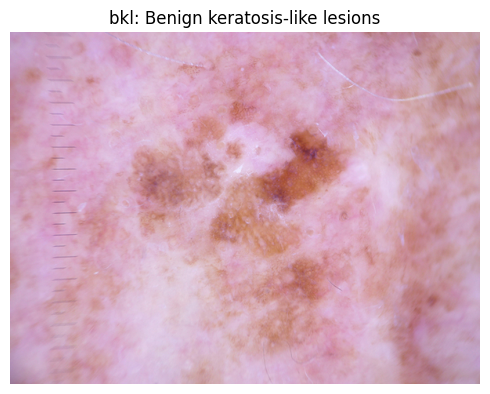

In [7]:
example_row = df.iloc[0]

with Image.open(
    example_row["image_path"]
) as example_image:

    plt.figure(figsize=(5, 5))

    plt.imshow(
        example_image.convert("RGB")
    )

plt.title(
    f"{example_row['dx']}: "
    f"{lesion_names[example_row['dx']]}"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc",
]

class_to_number = {
    class_name: number
    for number, class_name
    in enumerate(class_names)
}

number_to_class = {
    number: class_name
    for class_name, number
    in class_to_number.items()
}

df["label"] = df["dx"].map(
    class_to_number
)

if df["label"].isna().any():
    raise ValueError(
        "At least one diagnosis code was not mapped."
    )

df["label"] = df["label"].astype(int)

print("Class names:", class_names)
print("Class mapping:", class_to_number)

Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [9]:
from sklearn.model_selection import GroupShuffleSplit

first_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED,
)

train_indices, temporary_indices = next(
    first_split.split(
        df,
        groups=df["lesion_id"],
    )
)

train_df = df.iloc[
    train_indices
].reset_index(drop=True)

temporary_df = df.iloc[
    temporary_indices
].reset_index(drop=True)

second_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED,
)

validation_indices, test_indices = next(
    second_split.split(
        temporary_df,
        groups=temporary_df["lesion_id"],
    )
)

validation_df = temporary_df.iloc[
    validation_indices
].reset_index(drop=True)

test_df = temporary_df.iloc[
    test_indices
].reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Testing images:", len(test_df))
def print_class_distribution(
    split_name,
    dataframe
):
    counts = (
        dataframe["dx"]
        .value_counts()
        .reindex(
            class_names,
            fill_value=0
        )
    )

    percentages = (
        dataframe["dx"]
        .value_counts(normalize=True)
        .mul(100)
        .reindex(
            class_names,
            fill_value=0
        )
        .round(2)
    )

    summary = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
    })

    print(
        f"\n{split_name} distribution:"
    )

    print(summary)


print_class_distribution(
    "Training",
    train_df
)

print_class_distribution(
    "Validation",
    validation_df
)

print_class_distribution(
    "Testing",
    test_df
)

Training images: 7002
Validation images: 1519
Testing images: 1494

Training distribution:
       count  percentage
dx                      
akiec    207        2.96
bcc      381        5.44
bkl      741       10.58
df        89        1.27
mel      770       11.00
nv      4718       67.38
vasc      96        1.37

Validation distribution:
       count  percentage
dx                      
akiec     57        3.75
bcc       65        4.28
bkl      206       13.56
df        19        1.25
mel      156       10.27
nv       991       65.24
vasc      25        1.65

Testing distribution:
       count  percentage
dx                      
akiec     63        4.22
bcc       68        4.55
bkl      152       10.17
df         7        0.47
mel      187       12.52
nv       996       66.67
vasc      21        1.41


In [10]:
train_lesions = set(
    train_df["lesion_id"]
)

validation_lesions = set(
    validation_df["lesion_id"]
)

test_lesions = set(
    test_df["lesion_id"]
)

train_validation_overlap = (
    train_lesions
    & validation_lesions
)

train_test_overlap = (
    train_lesions
    & test_lesions
)

validation_test_overlap = (
    validation_lesions
    & test_lesions
)

print(
    "Train-validation overlap:",
    len(train_validation_overlap)
)

print(
    "Train-test overlap:",
    len(train_test_overlap)
)

print(
    "Validation-test overlap:",
    len(validation_test_overlap)
)

assert not train_validation_overlap
assert not train_test_overlap
assert not validation_test_overlap

print(
    "Lesion-group leakage check passed."
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0
Lesion-group leakage check passed.


In [11]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUMBER_OF_CLASSES = len(class_names)

print("Number of classes:", NUMBER_OF_CLASSES)

Number of classes: 7


In [12]:
def load_image(
    image_path,
    label
):
    image = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMAGE_SIZE, IMAGE_SIZE],
        method="bilinear",
        antialias=True,
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image.set_shape(
        [
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ]
    )

    label = tf.cast(
        label,
        tf.int32
    )
    return image, label

In [13]:
def create_dataset(
    dataframe,
    training=False
):
    image_paths = (
        dataframe["image_path"]
        .to_numpy()
    )

    labels = (
        dataframe["label"]
        .to_numpy(
            dtype=np.int32
        )
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (image_paths, labels)
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=(
            tf.data.AUTOTUNE
        ),
        deterministic=not training,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [14]:
train_dataset = create_dataset(
    train_df,
    training=True
)
validation_dataset = create_dataset(
    validation_df
)
test_dataset = create_dataset(
    test_df
)
print(train_dataset)
print(validation_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


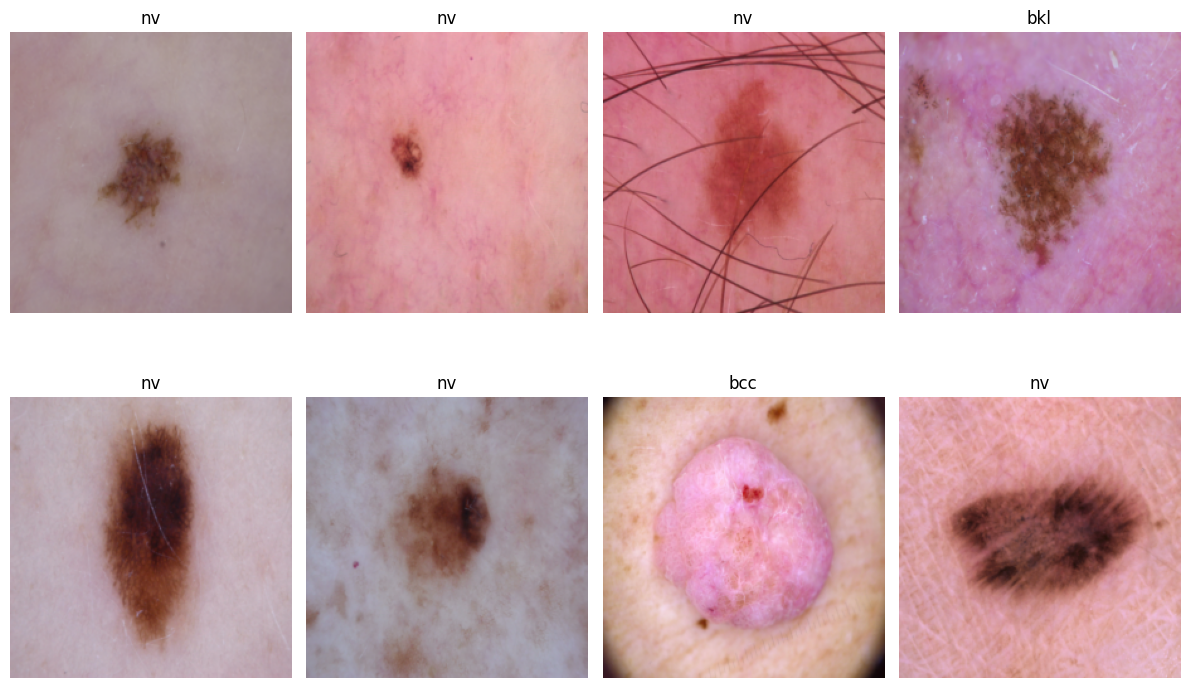

In [15]:
plt.figure(figsize=(12, 8))
for images, labels in train_dataset.take(1):
    number_to_show = min(
        8,
        len(images)
    )
    for index in range(number_to_show):
        plt.subplot(
            2,
            4,
            index + 1
        )
        plt.imshow(
            tf.cast(
                images[index],
                tf.uint8
            )
        )
        label_number = int(labels[index].numpy())
        class_code = number_to_class[label_number]
        plt.title(class_code)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal_and_vertical",
            seed=SEED,
        ),
        tf.keras.layers.RandomRotation(
            0.10,
            seed=SEED,
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED,
        ),
        tf.keras.layers.RandomContrast(
            0.10,
            seed=SEED,
        ),
    ],
    name="data_augmentation",
)

In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(
        NUMBER_OF_CLASSES
    ),
    y=train_df["label"].to_numpy(),
)

class_weights = {
    class_number: float(weight)
    for class_number, weight
    in enumerate(class_weight_values)
}

print("Class weights:")

for class_number, weight in class_weights.items():
    class_code = number_to_class[
        class_number
    ]

    print(
        f"{class_code}: {weight:.3f}"
    )

Class weights:
akiec: 4.832
bcc: 2.625
bkl: 1.350
df: 11.239
mel: 1.299
nv: 0.212
vasc: 10.420


In [18]:
base_model = (
    tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3,
        ),
    )
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3,
    ),
    name="image",
)

x = data_augmentation(
    inputs
)

x = base_model(
    x,
    training=False
)

x = (
    tf.keras.layers
    .GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)
)

x = tf.keras.layers.Dropout(
    0.30,
    name="dropout",
)(x)

outputs = tf.keras.layers.Dense(
    NUMBER_OF_CLASSES,
    activation="softmax",
    kernel_regularizer=(
        tf.keras.regularizers.l2(
            1e-4
        )
    ),
    name="lesion_probabilities",
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="HAM10000_EfficientNetB0",
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "HAM10000_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lesion_probabilities (Dense)    │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=(
        tf.keras.losses
        .SparseCategoricalCrossentropy()
    ),
    metrics=[
        tf.keras.metrics
        .SparseCategoricalAccuracy(
            name="accuracy"
        )
    ],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_initial_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.CSVLogger(
        "initial_training_log.csv"
    ),
]

In [20]:
INITIAL_EPOCHS = 15
initial_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.3709 - loss: 1.7938
Epoch 1: val_loss improved from None to 1.36401, saving model to best_initial_model.keras

Epoch 1: finished saving model to best_initial_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 113s 441ms/step - accuracy: 0.4257 - loss: 1.6502 - val_accuracy: 0.5069 - val_loss: 1.3640 - learning_rate: 0.0010
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5025 - loss: 1.3892
Epoch 2: val_loss improved from 1.36401 to 1.25153, saving model to best_initial_model.keras

Epoch 2: finished saving model to best_initial_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 72s 328ms/step - accuracy: 0.5196 - loss: 1.3517 - val_accuracy: 0.5490 - val_loss: 1.2515 - learning_rate: 0.0010
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.5493 - loss: 1.2016
Epoch 3: val_loss improved from 1.25153 to 1.11666, saving model to best_initial_model.keras

Epoch 3: finished saving model to best_initial_mod

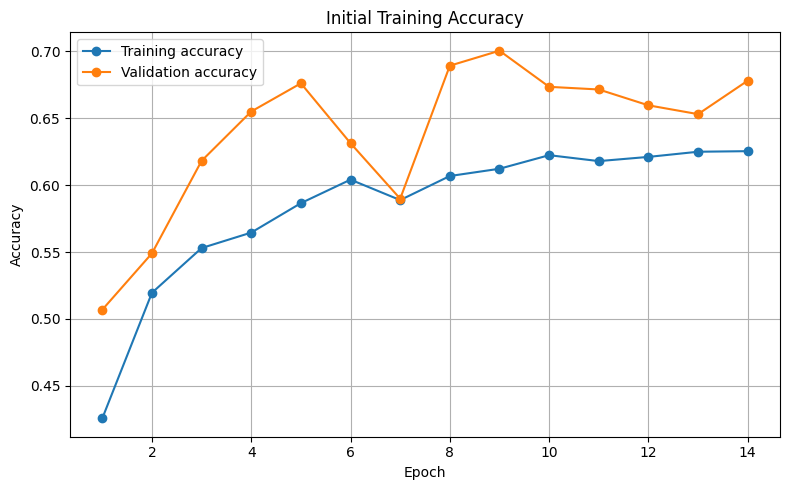

In [21]:
initial_epochs_run = range(
    1,
    len(initial_history.history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    initial_epochs_run,
    initial_history.history["accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    initial_epochs_run,
    initial_history.history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Initial Training Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "initial_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

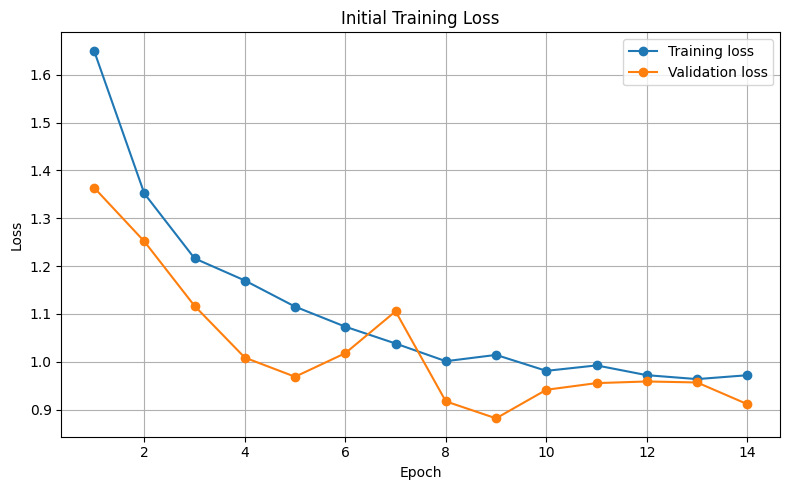

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    initial_epochs_run,
    initial_history.history["loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    initial_epochs_run,
    initial_history.history["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Initial Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "initial_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

trainable_base_layers = sum(
    int(layer.trainable)
    for layer in base_model.layers
)

print(
    "Trainable EfficientNet layers:",
    trainable_base_layers
)

Trainable EfficientNet layers: 15


In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [25]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_finetuned_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        "fine_tuning_log.csv"
    )
]

In [26]:
FINE_TUNE_EPOCHS = 10
fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.6494 - loss: 0.9535
Epoch 1: val_loss improved from None to 0.92556, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 87s 342ms/step - accuracy: 0.6320 - loss: 0.9790 - val_accuracy: 0.6695 - val_loss: 0.9256 - learning_rate: 1.0000e-05
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.6190 - loss: 0.9487
Epoch 2: val_loss improved from 0.92556 to 0.90420, saving model to best_finetuned_model.keras

Epoch 2: finished saving model to best_finetuned_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 79s 361ms/step - accuracy: 0.6302 - loss: 0.9313 - val_accuracy: 0.6814 - val_loss: 0.9042 - learning_rate: 1.0000e-05
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6249 - loss: 0.9341
Epoch 3: val_loss improved from 0.90420 to 0.87457, saving model to best_finetuned_model.keras

Epoch 3: finished saving model to

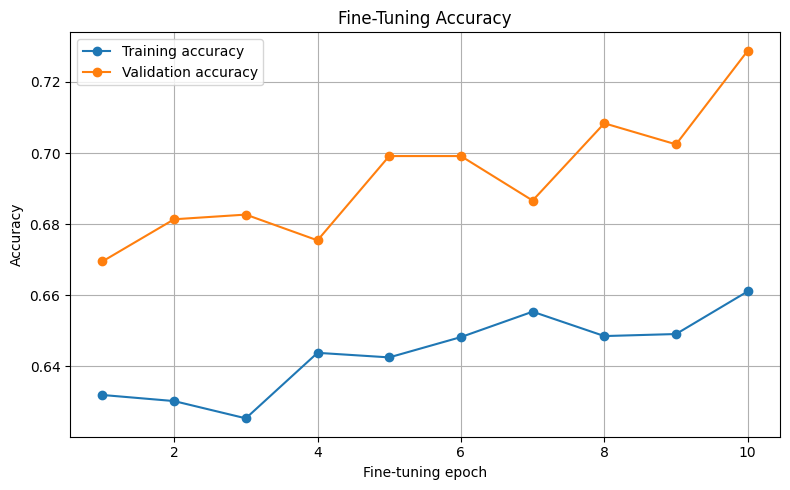

In [27]:
fine_tune_epochs_run = range(
    1,
    len(fine_tune_history.history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_epochs_run,
    fine_tune_history.history["accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    fine_tune_epochs_run,
    fine_tune_history.history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

plt.xlabel("Fine-tuning epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "fine_tuning_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

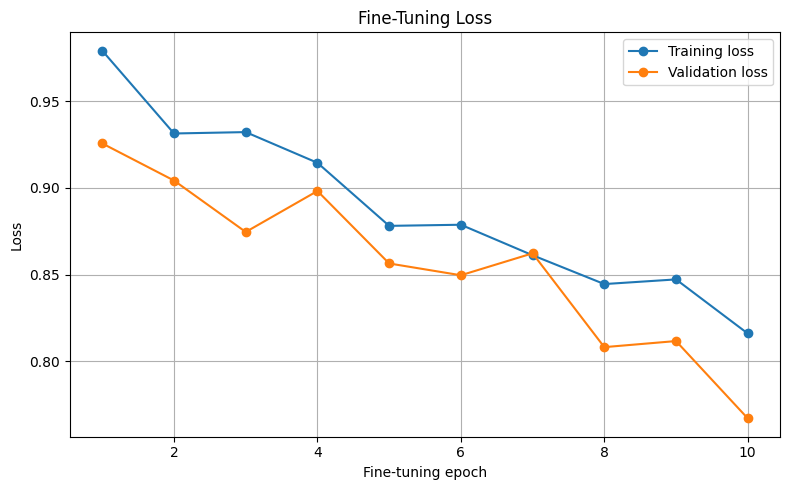

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_epochs_run,
    fine_tune_history.history["loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    fine_tune_epochs_run,
    fine_tune_history.history["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Fine-tuning epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "fine_tuning_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
initial_best_val_loss = min(
    initial_history.history["val_loss"]
)

finetuned_best_val_loss = min(
    fine_tune_history.history["val_loss"]
)

if finetuned_best_val_loss < initial_best_val_loss:
    best_model_path = "best_finetuned_model.keras"
else:
    best_model_path = "best_initial_model.keras"

model = tf.keras.models.load_model(
    best_model_path
)

print("Loaded:", best_model_path)

Loaded: best_finetuned_model.keras


In [30]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 371ms/step - accuracy: 0.7249 - loss: 0.7651
Test loss: 0.7651
Test accuracy: 0.7249


In [31]:
true_labels = np.concatenate(
    [
        labels.numpy()
        for _, labels in test_dataset
    ]
).astype(int)

prediction_probabilities = model.predict(
    test_dataset,
    verbose=1
)

predicted_labels = np.argmax(
    prediction_probabilities,
    axis=1
)

print(
    "Number of predictions:",
    len(predicted_labels)
)

assert len(true_labels) == len(test_df)
assert len(predicted_labels) == len(test_df)

47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 313ms/step
Number of predictions: 1494


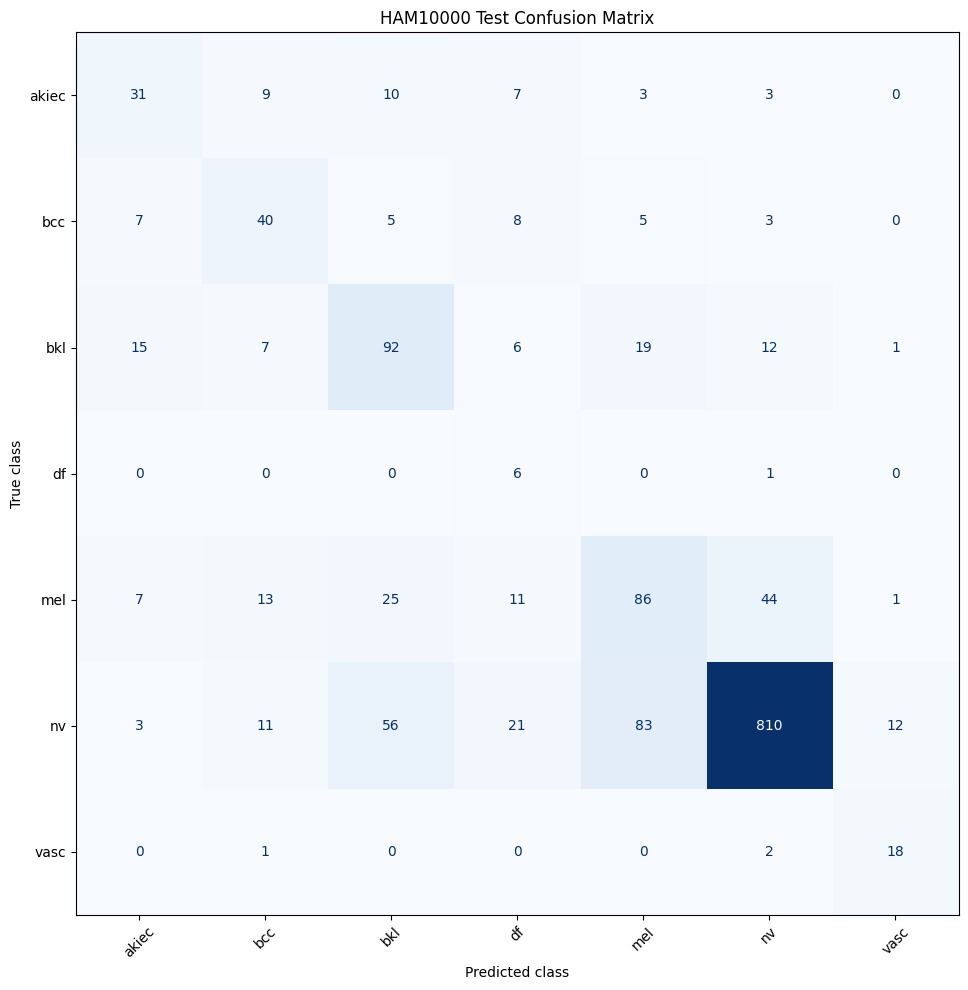

In [32]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix
)

matrix = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(NUMBER_OF_CLASSES)
)

figure, axis = plt.subplots(
    figsize=(10, 10)
)

matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names
)

matrix_display.plot(
    ax=axis,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("HAM10000 Test Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

balanced_accuracy = balanced_accuracy_score(
    true_labels,
    predicted_labels
)

macro_precision = precision_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced accuracy: {balanced_accuracy:.4f}")
print(f"Macro precision: {macro_precision:.4f}")
print(f"Macro recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

print("\nClassification report:")

print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=np.arange(NUMBER_OF_CLASSES),
        target_names=class_names,
        zero_division=0
    )
)

Accuracy: 0.7249
Balanced accuracy: 0.6676
Macro precision: 0.5006
Macro recall: 0.6676
Macro F1: 0.5352
Weighted F1: 0.7441

Classification report:
              precision    recall  f1-score   support

       akiec       0.49      0.49      0.49        63
         bcc       0.49      0.59      0.54        68
         bkl       0.49      0.61      0.54       152
          df       0.10      0.86      0.18         7
         mel       0.44      0.46      0.45       187
          nv       0.93      0.81      0.87       996
        vasc       0.56      0.86      0.68        21

    accuracy                           0.72      1494
   macro avg       0.50      0.67      0.54      1494
weighted avg       0.77      0.72      0.74      1494



In [34]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

true_labels_binary = label_binarize(
    true_labels,
    classes=np.arange(NUMBER_OF_CLASSES)
)

macro_roc_auc = roc_auc_score(
    true_labels_binary,
    prediction_probabilities,
    average="macro",
    multi_class="ovr"
)

weighted_roc_auc = roc_auc_score(
    true_labels_binary,
    prediction_probabilities,
    average="weighted",
    multi_class="ovr"
)

print(
    f"Macro one-vs-rest ROC-AUC: "
    f"{macro_roc_auc:.4f}"
)

print(
    f"Weighted one-vs-rest ROC-AUC: "
    f"{weighted_roc_auc:.4f}"
)

Macro one-vs-rest ROC-AUC: 0.9239
Weighted one-vs-rest ROC-AUC: 0.9099


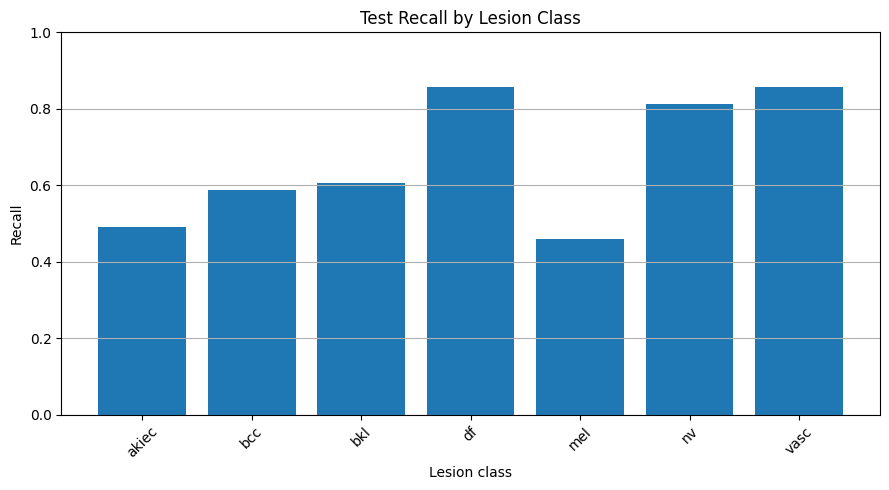

In [35]:
per_class_recall = recall_score(
    true_labels,
    predicted_labels,
    labels=np.arange(NUMBER_OF_CLASSES),
    average=None,
    zero_division=0
)

plt.figure(figsize=(9, 5))

plt.bar(
    class_names,
    per_class_recall
)

plt.ylim(0, 1)
plt.xlabel("Lesion class")
plt.ylabel("Recall")
plt.title("Test Recall by Lesion Class")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    "per_class_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
results_df = test_df.copy()

results_df["predicted_label"] = predicted_labels

results_df["predicted_code"] = (
    results_df["predicted_label"]
    .map(number_to_class)
)

results_df["confidence"] = np.max(
    prediction_probabilities,
    axis=1
)

results_df["true_class_probability"] = (
    prediction_probabilities[
        np.arange(len(true_labels)),
        true_labels
    ]
)

sorted_probabilities = np.sort(
    prediction_probabilities,
    axis=1
)

results_df["prediction_margin"] = (
    sorted_probabilities[:, -1]
    - sorted_probabilities[:, -2]
)

mistakes_df = results_df[
    results_df["label"]
    != results_df["predicted_label"]
].copy()

mistakes_df = mistakes_df.sort_values(
    "confidence",
    ascending=False
)

print(
    "Number of mistakes:",
    len(mistakes_df)
)

print(
    mistakes_df[
        [
            "image_id",
            "dx",
            "predicted_code",
            "confidence",
            "true_class_probability",
            "prediction_margin"
        ]
    ].head(10)
)

Number of mistakes: 411
          image_id     dx predicted_code  confidence  true_class_probability  \
359   ISIC_0029877   vasc             nv    0.978923                0.001874   
1251  ISIC_0024793     nv           vasc    0.967467                0.009565   
315   ISIC_0031529    mel             nv    0.961760                0.027645   
296   ISIC_0028760    mel             nv    0.947862                0.036230   
1250  ISIC_0031340     nv           vasc    0.941573                0.020575   
1441  ISIC_0028132  akiec            bcc    0.933532                0.025017   
485   ISIC_0025366    bkl             nv    0.929015                0.011875   
1440  ISIC_0029362  akiec            bcc    0.923131                0.022879   
393   ISIC_0026528    bcc             df    0.918123                0.008152   
217   ISIC_0034087    mel             nv    0.913746                0.063369   

      prediction_margin  
359            0.969537  
1251           0.952894  
315            0.

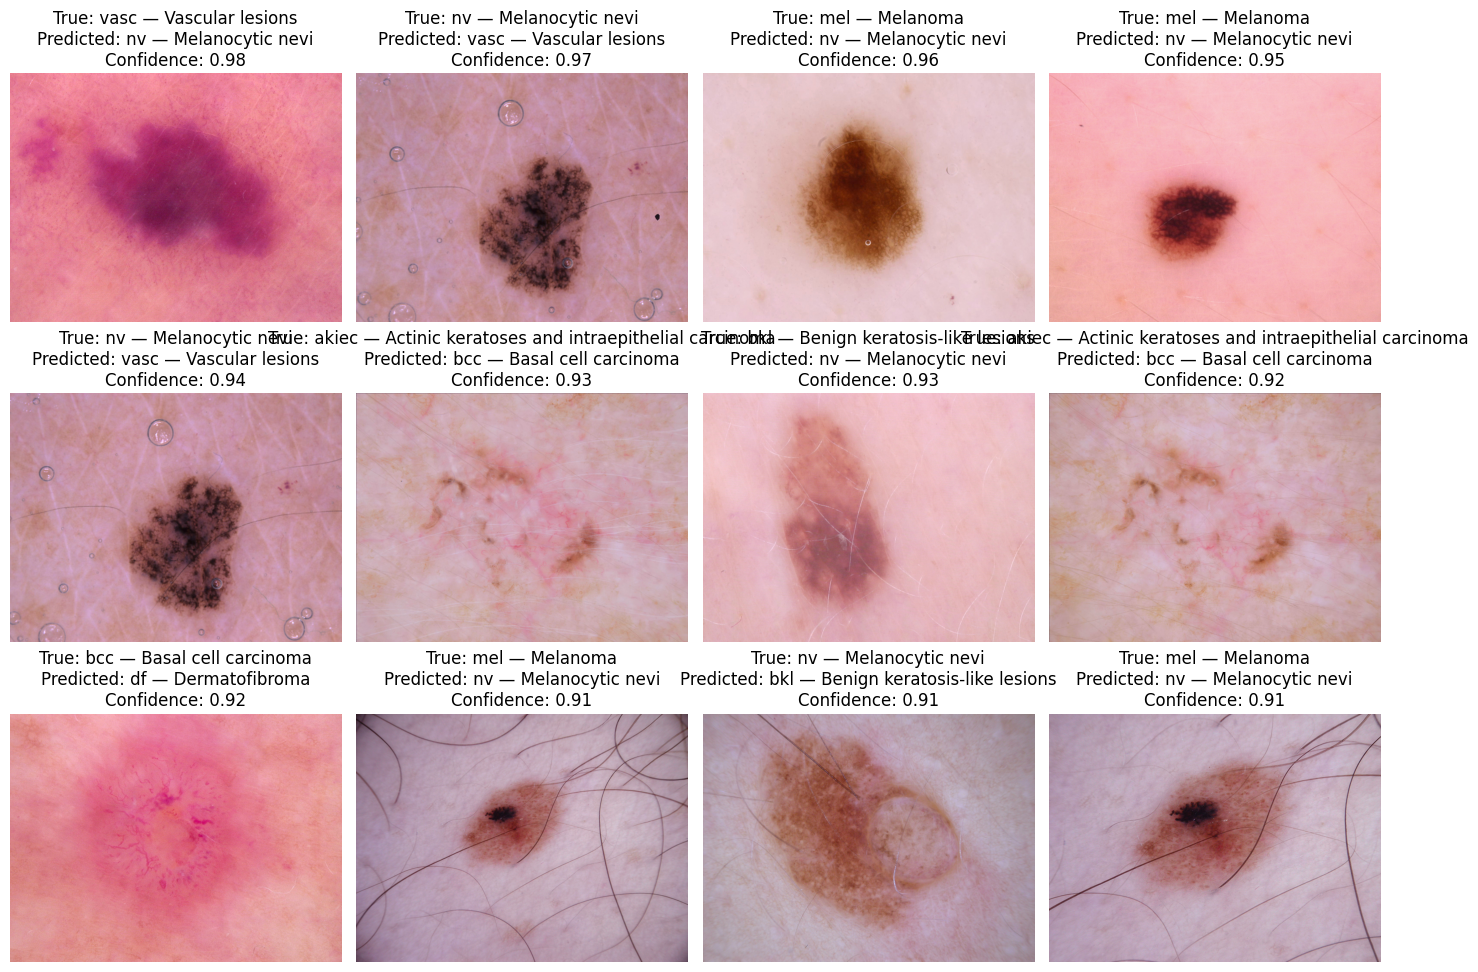

In [37]:
plt.figure(figsize=(14, 10))

number_to_display = min(
    12,
    len(mistakes_df)
)

for index in range(number_to_display):
    row = mistakes_df.iloc[index]

    with Image.open(
        row["image_path"]
    ) as image:
        display_image = image.convert("RGB").copy()

    plt.subplot(
        3,
        4,
        index + 1
    )

    plt.imshow(display_image)

    true_name = lesion_names[
        row["dx"]
    ]

    predicted_name = lesion_names[
        row["predicted_code"]
    ]

    plt.title(
        f"True: {row['dx']} — {true_name}\n"
        f"Predicted: {row['predicted_code']} — "
        f"{predicted_name}\n"
        f"Confidence: {row['confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "high_confidence_mistakes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
error_pairs = (
    mistakes_df
    .groupby(
        ["dx", "predicted_code"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print("Most common confusion pairs:")
print(error_pairs.head(15))

Most common confusion pairs:
       dx predicted_code  count
27     nv            mel     83
25     nv            bkl     56
21    mel             nv     44
19    mel            bkl     25
26     nv             df     21
13    bkl            mel     19
10    bkl          akiec     15
18    mel            bcc     13
28     nv           vasc     12
14    bkl             nv     12
20    mel             df     11
24     nv            bcc     11
1   akiec            bkl     10
0   akiec            bcc      9
7     bcc             df      8


In [39]:
model.save(
    "HAM10000_EfficientNetB0_Best.keras"
)
print("Best model saved.")

Best model saved.


In [40]:
for class_number, class_code in (
    number_to_class.items()
):
    results_df[
        f"probability_{class_code}"
    ] = prediction_probabilities[
        :,
        class_number
    ]

results_df.to_csv(
    "HAM10000_test_predictions.csv",
    index=False
)

mistakes_df.to_csv(
    "HAM10000_mistakes.csv",
    index=False
)

error_pairs.to_csv(
    "HAM10000_error_pairs.csv",
    index=False
)

print(
    "Prediction and error-analysis files saved."
)

Prediction and error-analysis files saved.


In [41]:
results_summary = {
    "dataset": "HAM10000",
    "model": "EfficientNetB0",
    "split_method": (
        "70/15/15 lesion-grouped split using lesion_id"
    ),
    "random_seed": SEED,
    "number_of_classes": int(
        NUMBER_OF_CLASSES
    ),
    "training_images": int(
        len(train_df)
    ),
    "validation_images": int(
        len(validation_df)
    ),
    "testing_images": int(
        len(test_df)
    ),
    "accuracy": float(
        accuracy
    ),
    "balanced_accuracy": float(
        balanced_accuracy
    ),
    "macro_precision": float(
        macro_precision
    ),
    "macro_recall": float(
        macro_recall
    ),
    "macro_f1": float(
        macro_f1
    ),
    "weighted_f1": float(
        weighted_f1
    ),
    "macro_roc_auc_ovr": float(
        macro_roc_auc
    ),
    "weighted_roc_auc_ovr": float(
        weighted_roc_auc
    ),
    "number_of_test_errors": int(
        len(mistakes_df)
    ),
    "disclaimer": (
        "Educational machine-learning research only. "
        "Not a medical diagnostic system."
    )
}

with open(
    "HAM10000_results.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        results_summary,
        file,
        indent=4
    )

print(results_summary)

{'dataset': 'HAM10000', 'model': 'EfficientNetB0', 'split_method': '70/15/15 lesion-grouped split using lesion_id', 'random_seed': 42, 'number_of_classes': 7, 'training_images': 7002, 'validation_images': 1519, 'testing_images': 1494, 'accuracy': 0.7248995983935743, 'balanced_accuracy': 0.6675705312197321, 'macro_precision': 0.5005624379796548, 'macro_recall': 0.6675705312197321, 'macro_f1': 0.5351642116590095, 'weighted_f1': 0.7440887771990934, 'macro_roc_auc_ovr': 0.9239002998812736, 'weighted_roc_auc_ovr': 0.9098655176391884, 'number_of_test_errors': 411, 'disclaimer': 'Educational machine-learning research only. Not a medical diagnostic system.'}
